<a href="https://colab.research.google.com/github/1BM23CS345/6Sem_ML_Lab/blob/main/lab_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
try:
    df = pd.read_csv('/content/Fraud.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'synthetic_fraud_dataset.csv' not found. Please ensure the file is uploaded to '/content/'.")
    df = None

Dataset loaded successfully.


In [4]:
if df is not None:
    print("\nFirst 5 rows of the dataset:")
    display(df.head())

    print("\nDataset Information:")
    df.info()

    print("\nDescriptive Statistics:")
    display(df.describe())


First 5 rows of the dataset:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2601180 entries, 0 to 2601179
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         float64
 10  isFlaggedFraud  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 218.3+ MB

Descriptive Statistics:


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,2.601180e+06,2.601179e+06,2.601179e+06,2.601179e+06,2.601179e+06,2.601179e+06,2.601179e+06,2601179.0
mean,1.095988e+02,1.582683e+05,8.514950e+05,8.730084e+05,9.959188e+05,1.106199e+06,8.903655e-04,0.0
std,7.134401e+01,2.640875e+05,2.930665e+06,2.967015e+06,2.301125e+06,2.386048e+06,2.982571e-02,0.0
min,1.000000e+00,2.000000e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
25%,3.500000e+01,1.265122e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
50%,1.360000e+02,7.745840e+04,1.483300e+04,0.000000e+00,1.394917e+05,2.277577e+05,0.000000e+00,0.0
75%,1.780000e+02,2.136462e+05,1.165750e+05,1.576628e+05,9.479042e+05,1.138147e+06,0.000000e+00,0.0
max,2.080000e+02,1.000000e+07,3.893942e+07,3.894623e+07,4.228378e+07,4.265577e+07,1.000000e+00,0.0


In [ ]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

if 'df' not in locals() or df is None:
    try:
        df = pd.read_csv('/content/Fraud.csv')
        print("Dataset reloaded for preprocessing.")
    except FileNotFoundError:
        print("Error: 'synthetic_fraud_dataset.csv' not found. Please ensure the file is uploaded to '/content/'.")
        df = None

if df is not None:

    target_column = 'Fraud_Label'
    identifier_columns = ['Transaction_ID', 'User_ID']

    columns_to_drop = identifier_columns + ['Timestamp']

    df_processed = df.drop(columns=columns_to_drop, errors='ignore')

    categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()

    df_encoded = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

    X = df_encoded.drop(target_column, axis=1)
    y = df_encoded[target_column]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    print("\nData Preprocessing Summary:")
    print(f"Original features: {df.shape[1]}")
    print(f"Columns dropped: {columns_to_drop}")
    print(f"Categorical columns encoded: {categorical_cols}")
    print(f"New number of features after one-hot encoding: {X.shape[1]}")
    print(f"Training set shape: {X_train.shape, y_train.shape}")
    print(f"Testing set shape: {X_test.shape, y_test.shape}")
else:
    print("Cannot proceed with preprocessing as DataFrame is not loaded.")

In [9]:
if 'X_train' in locals() and 'y_train' in locals():
    print("\n--- Training Random Forest Classifier ---")
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_train)


    y_pred_rf = rf_model.predict(X_test)

    print("\nRandom Forest Classifier Performance:")
    print("Accuracy:", accuracy_score(y_test, y_pred_rf))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
    print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
else:
    print("Training data (X_train, y_train) not found. Please ensure preprocessing was successful.")


--- Training Random Forest Classifier ---

Random Forest Classifier Performance:
Accuracy: 1.0

Confusion Matrix:
 [[10180     0]
 [    0  4820]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     10180
           1       1.00      1.00      1.00      4820

    accuracy                           1.00     15000
   macro avg       1.00      1.00      1.00     15000
weighted avg       1.00      1.00      1.00     15000



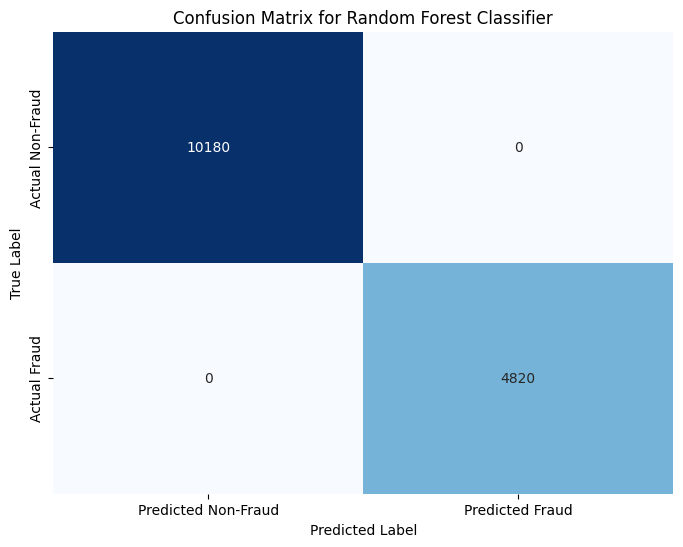

In [11]:
if 'y_test' in locals() and 'y_pred_rf' in locals():
    cm = confusion_matrix(y_test, y_pred_rf)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False,
                xticklabels=['Predicted Non-Fraud', 'Predicted Fraud'],
                yticklabels=['Actual Non-Fraud', 'Actual Fraud'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix for Random Forest Classifier')
    plt.show()
else:
    print("Test labels (y_test) or Random Forest predictions (y_pred_rf) not found.")

/tmp/ipykernel_10121/762595093.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')


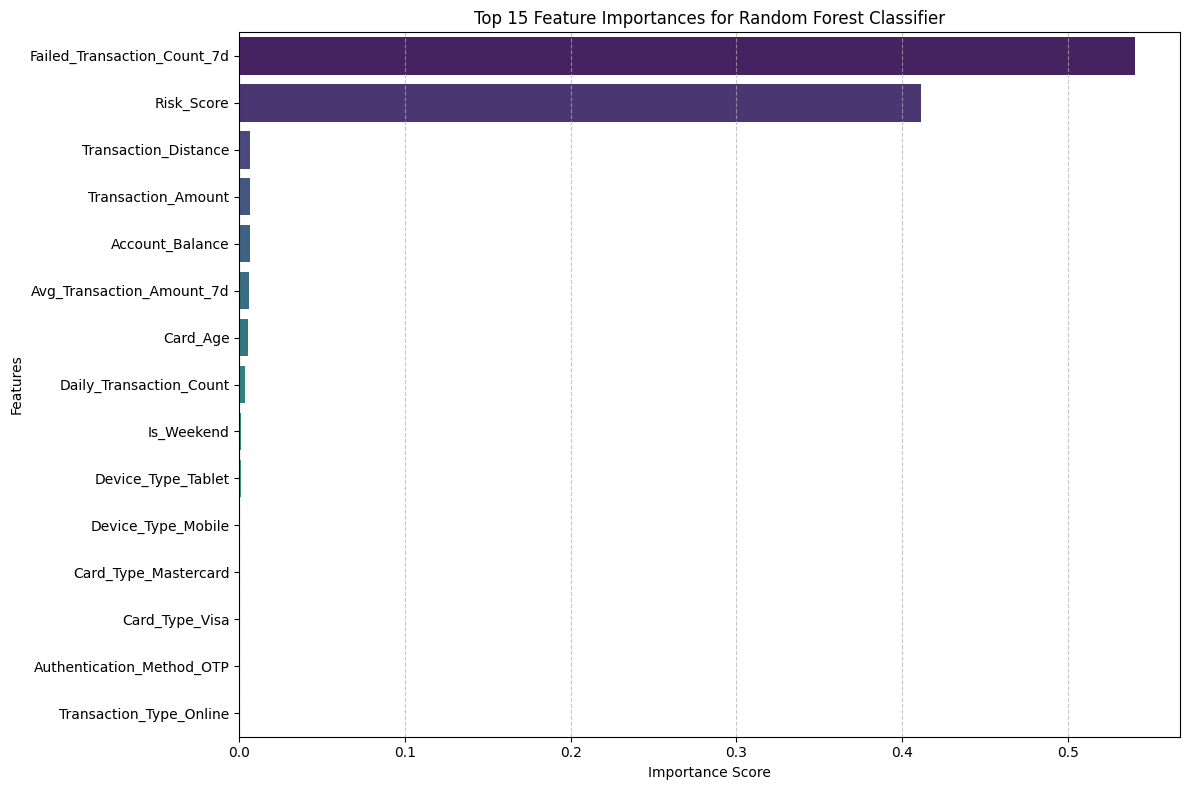

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top_features = feature_importances.nlargest(15) # Display top 15 features

plt.figure(figsize=(12, 8))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
plt.title('Top 15 Feature Importances for Random Forest Classifier')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [6]:
if 'X_train' in locals() and 'y_train' in locals():
    print("\n--- Training AdaBoost Classifier ---")


    base_estimator = DecisionTreeClassifier(max_depth=1, random_state=42)
    adaboost_model = AdaBoostClassifier(estimator=base_estimator, n_estimators=100, random_state=42)
    adaboost_model.fit(X_train, y_train)

    y_pred_ada = adaboost_model.predict(X_test)

    print("\nAdaBoost Classifier Performance:")
    print("Accuracy:", accuracy_score(y_test, y_pred_ada))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_ada))
    print("\nClassification Report:\n", classification_report(y_test, y_pred_ada))
else:
    print("Training data (X_train, y_train) not found. Please ensure preprocessing was successful.")


--- Training AdaBoost Classifier ---

AdaBoost Classifier Performance:
Accuracy: 1.0

Confusion Matrix:
 [[10180     0]
 [    0  4820]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     10180
           1       1.00      1.00      1.00      4820

    accuracy                           1.00     15000
   macro avg       1.00      1.00      1.00     15000
weighted avg       1.00      1.00      1.00     15000

